In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt

In [2]:
occupancy = pd.read_csv(
    "../data/raw/occupancy.csv"
)

time_df = pd.read_csv(
    "../data/raw/time.csv"
)

In [3]:
occupancy = pd.read_csv(
    "../data/raw/occupancy.csv"
)

time_df = pd.read_csv(
    "../data/raw/time.csv"
)

In [4]:
occupancy = pd.read_csv(
    "../data/raw/occupancy.csv"
)

time_df = pd.read_csv(
    "../data/raw/time.csv"
)

In [5]:
urban["hour_sin"] = np.sin(
    2*np.pi*urban["hour"]/24
)

urban["hour_cos"] = np.cos(
    2*np.pi*urban["hour"]/24
)

NameError: name 'urban' is not defined

In [6]:
urban = pd.concat(
    [
        time_df,
        occupancy["network_demand"]
    ],
    axis=1
)

urban.head()

KeyError: 'network_demand'

In [7]:
print(occupancy.shape)
print(occupancy.columns[:10])

(8640, 248)
Index(['timestamp', '102', '105', '107', '108', '109', '110', '111', '115',
       '123'],
      dtype='object')


In [8]:
occupancy.head()

,timestamp,102,105,107,108,109,110,111,115,123,...,1160,1162,1163,1164,1166,1167,1168,1170,1172,1173
0,1,12,16,24,15,6,8,24,1,2,...,0,12,1,38,26,162,10,1,8,15
1,2,12,16,24,15,6,8,24,1,2,...,0,12,1,38,26,162,10,1,8,15
2,3,12,16,24,15,6,8,24,1,2,...,0,12,1,38,26,164,10,1,8,15
3,4,12,16,24,15,6,8,24,1,2,...,0,12,1,38,26,166,10,1,8,15
4,5,12,16,24,15,6,8,24,1,2,...,0,12,1,38,26,168,10,1,8,15


In [9]:
station_cols = occupancy.columns.drop("timestamp")

occupancy["network_demand"] = (
    occupancy[station_cols]
    .mean(axis=1)
)

occupancy[["timestamp", "network_demand"]].head()

,timestamp,network_demand
0,1,24.352227
1,2,24.356275
2,3,24.643725
3,4,24.923077
4,5,25.072874


In [10]:
print("network_demand" in occupancy.columns)

True


In [11]:
urban = pd.concat(
    [
        time_df,
        occupancy["network_demand"]
    ],
    axis=1
)

urban.head()

,month,day,year,hour,minute,second,network_demand
0,6,19,2022,0,0,0,24.352227
1,6,19,2022,0,5,0,24.356275
2,6,19,2022,0,10,0,24.643725
3,6,19,2022,0,15,0,24.923077
4,6,19,2022,0,20,0,25.072874


In [12]:
urban["hour_sin"] = np.sin(
    2 * np.pi * urban["hour"] / 24
)

urban["hour_cos"] = np.cos(
    2 * np.pi * urban["hour"] / 24
)

urban.head()

,month,day,year,hour,minute,second,network_demand,hour_sin,hour_cos
0,6,19,2022,0,0,0,24.352227,0.0,1.0
1,6,19,2022,0,5,0,24.356275,0.0,1.0
2,6,19,2022,0,10,0,24.643725,0.0,1.0
3,6,19,2022,0,15,0,24.923077,0.0,1.0
4,6,19,2022,0,20,0,25.072874,0.0,1.0


In [13]:
urban["lag_1"] = (
    urban["network_demand"]
    .shift(1)
)

urban = urban.dropna()

urban.head()

,month,day,year,hour,minute,second,network_demand,hour_sin,hour_cos,lag_1
1,6,19,2022,0,5,0,24.356275,0.0,1.0,24.352227
2,6,19,2022,0,10,0,24.643725,0.0,1.0,24.356275
3,6,19,2022,0,15,0,24.923077,0.0,1.0,24.643725
4,6,19,2022,0,20,0,25.072874,0.0,1.0,24.923077
5,6,19,2022,0,25,0,25.238866,0.0,1.0,25.072874


In [14]:
X = urban[
    [
        "hour",
        "month",
        "hour_sin",
        "hour_cos",
        "lag_1"
    ]
]

y = urban["network_demand"]

print(X.shape)
print(y.shape)

(8639, 5)
(8639,)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(6911, 5)
(1728, 5)


In [16]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train,
    y_train
)

RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)

In [17]:
preds = rf.predict(X_test)

In [18]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_test,
    preds
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        preds
    )
)

r2 = r2_score(
    y_test,
    preds
)

print("MAE :", mae)
print("RMSE:", rmse)
print("R² :", r2)

MAE : 0.10950907327342697
RMSE: 0.31555710578802365
R² : 0.9918898635916663


In [19]:
importance = pd.DataFrame(
{
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}
)

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance

,Feature,Importance
4,lag_1,0.994785
3,hour_cos,0.001972
2,hour_sin,0.001633
0,hour,0.001266
1,month,0.000344


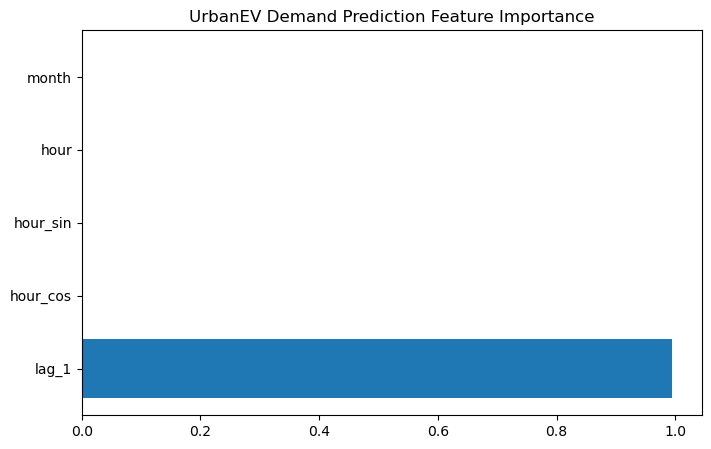

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title(
    "UrbanEV Demand Prediction Feature Importance"
)

plt.show()

In [21]:
import joblib

joblib.dump(
    rf,
    "../processed/urban_demand_model.pkl"
)

print("UrbanEV model saved successfully!")

UrbanEV model saved successfully!
